# Tarea 2 — Análisis Unificado de Escalabilidad KNN

Análisis sobre `results_knn.csv` (1728 filas) producido por `knn_sweep.sh` + `knn_runner.py`.

**Implementaciones comparadas (4 ramas de paralelismo):**

| rama | implementación | palanca de paralelismo |
|---|---|---|
| `sklearn-OMP`     | `sklearn-brute`, `n_jobs=1` | `OMP_NUM_THREADS` (kernel `PairwiseDistancesArgKmin`, OpenMP) |
| `sklearn-jobs`    | `sklearn-brute`, `OMP=1`   | `n_jobs` (joblib) |
| `manual-thread`   | `manual-brute`, `OMP=1`    | `n_jobs` (joblib threading) |
| `manual-loky`     | `manual-brute`, `OMP=1`    | `n_jobs` (joblib loky) |

**Convención de tamaño:** la dimensión "tamaño del problema" se reduce a `n_train`; se fija `n_features=88` y `n_test=1216` (los máximos del grid). El "caso grande" (BIG) es `n_train=232448`.

**Métrica principal:** `pred_time_s_avg` (fit es lazy en KNN brute).

**Complejidad teórica:** $T \propto \frac{n_{test} \cdot n_{train} \cdot d}{p}$.

## 0. Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

CSV_PATH = Path("results_knn.csv")
df_all = pd.read_csv(CSV_PATH)
for c in ["flops_total", "flops_distance", "flops_select"]:
    df_all[c] = df_all[c].astype(float)

# Fijamos n_features y n_test en su máximo; la única dimensión de tamaño es n_train.
N_FEAT_FIX = 88
N_TEST_FIX = 1216
df = df_all[(df_all["n_features"] == N_FEAT_FIX) & (df_all["n_test"] == N_TEST_FIX)].copy()

N_TRAIN_VALS = sorted(df["n_train"].unique())
N_TRAIN_BIG  = N_TRAIN_VALS[-1]   # 232448
P_VALS = [1, 2, 4, 8, 16, 32]

# Paleta consistente para las 4 ramas
BRANCH_COLORS = {
    "sklearn-OMP":   "#1f77b4",  # azul
    "sklearn-jobs":  "#ff7f0e",  # naranja
    "manual-thread": "#2ca02c",  # verde
    "manual-loky":   "#d62728",  # rojo
}

def extract_branch(df, branch, n_train):
    """Devuelve un DataFrame con columnas (p, pred_time) para una rama y n_train dados."""
    sub = df[df["n_train"] == n_train].copy()
    if branch == "sklearn-OMP":
        s = sub[(sub["implementation"] == "sklearn-brute") & (sub["n_jobs"] == 1)]
        s = s.rename(columns={"omp_num_threads": "p"})
    elif branch == "sklearn-jobs":
        s = sub[(sub["implementation"] == "sklearn-brute") & (sub["omp_num_threads"] == 1)]
        s = s.rename(columns={"n_jobs": "p"})
    elif branch == "manual-thread":
        s = sub[(sub["implementation"] == "manual-brute") & (sub["backend"] == "threading")]
        s = s.rename(columns={"n_jobs": "p"})
    elif branch == "manual-loky":
        s = sub[(sub["implementation"] == "manual-brute") & (sub["backend"] == "loky")]
        s = s.rename(columns={"n_jobs": "p"})
    else:
        raise ValueError(branch)
    return s[["p", "pred_time_s_avg", "flops_total"]].sort_values("p").reset_index(drop=True)

print(f"Filas tras filtro (d={N_FEAT_FIX}, n_test={N_TEST_FIX}): {len(df)}")
print(f"n_train values: {N_TRAIN_VALS}")
print(f"BIG: n_train={N_TRAIN_BIG}")
print(f"p values: {P_VALS}")

# Sanity: cada rama debe tener 6 puntos por n_train (excepto algún caso borde)
for b in BRANCH_COLORS:
    n = len(extract_branch(df, b, N_TRAIN_BIG))
    print(f"  rama {b}: {n} puntos en BIG")


Filas tras filtro (d=88, n_test=1216): 288
n_train values: [np.int64(227), np.int64(908), np.int64(3632), np.int64(14528), np.int64(58112), np.int64(232448)]
BIG: n_train=232448
p values: [1, 2, 4, 8, 16, 32]
  rama sklearn-OMP: 6 puntos en BIG
  rama sklearn-jobs: 6 puntos en BIG
  rama manual-thread: 6 puntos en BIG
  rama manual-loky: 6 puntos en BIG


## 1. Tiempo baseline (secuencial)

Tiempos a `p=1` para cada (implementación, backend) variando `n_train`. Validamos que la complejidad medida coincide con la teórica $T \propto n$.

In [2]:
# Tabla: pred_time(p=1) por (implementación, backend) y n_train
baseline = (df[(df["omp_num_threads"] == 1) & (df["n_jobs"] == 1)]
            .pivot_table(index=["implementation", "backend"],
                         columns="n_train", values="pred_time_s_avg")
            .sort_index())
print("Tiempo serial pred_time_s_avg [s] por (implementación, backend) × n_train:")
print(baseline.round(4))

# Throughput en BIG (FLOPs/s)
thr = (df[(df["omp_num_threads"] == 1) & (df["n_jobs"] == 1) & (df["n_train"] == N_TRAIN_BIG)]
       .assign(throughput=lambda d: d["flops_total"] / d["pred_time_s_avg"])
       [["implementation", "backend", "pred_time_s_avg", "throughput"]])
print(f"\nThroughput en BIG (n_train={N_TRAIN_BIG}):")
print(thr.to_string(index=False))


Tiempo serial pred_time_s_avg [s] por (implementación, backend) × n_train:
n_train                   227     908     3632    14528    58112     232448
implementation backend                                                     
manual-brute   loky       0.0641  0.2092  0.7057  2.7689  24.2523  103.0885
               threading  0.0619  0.2051  0.7594  3.1665  23.5617  102.9248
sklearn-brute  threading  0.0031  0.0083  0.0258  0.0957   0.3784    1.5483

Throughput en BIG (n_train=232448):
implementation   backend  pred_time_s_avg   throughput
 sklearn-brute threading           1.5483 4.908609e+10
  manual-brute threading         102.9248 7.384032e+08
  manual-brute      loky         103.0885 7.372306e+08


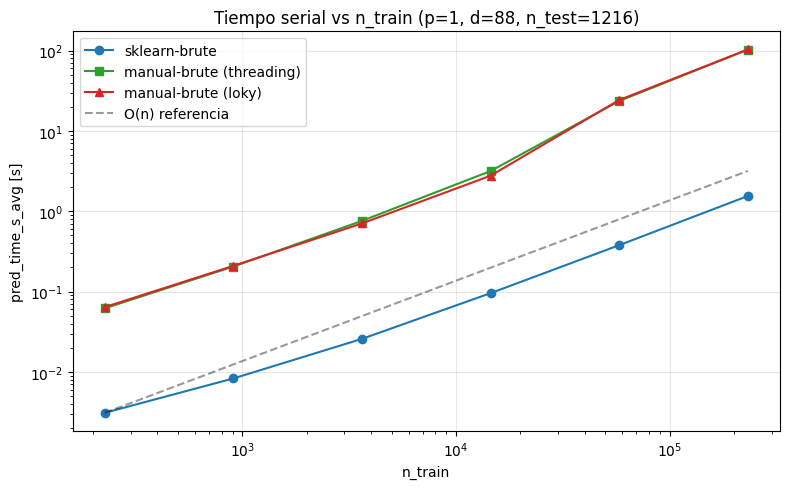

Pendiente del fit log-log:
  sklearn-brute: 0.903  (esperado ≈ 1 si T ∝ n_train)
  manual-brute (threading): 1.087


In [3]:
# Figura 1.1: pred_time vs n_train (p=1), una curva por (impl, backend)
fig, ax = plt.subplots()
serial = df[(df["omp_num_threads"] == 1) & (df["n_jobs"] == 1)]

curves = [
    ("sklearn-brute",  None,        BRANCH_COLORS["sklearn-OMP"],   "o"),
    ("manual-brute",   "threading", BRANCH_COLORS["manual-thread"], "s"),
    ("manual-brute",   "loky",      BRANCH_COLORS["manual-loky"],   "^"),
]
for impl, be, color, mk in curves:
    sub = serial[serial["implementation"] == impl]
    if be is not None:
        sub = sub[sub["backend"] == be]
    label = impl if be is None else f"{impl} ({be})"
    sub = sub.groupby("n_train")["pred_time_s_avg"].first().reset_index()
    ax.loglog(sub["n_train"], sub["pred_time_s_avg"], marker=mk, color=color, label=label)

# Referencia O(n): ancla en el punto sklearn-brute, n_train mínimo
ref_xs = np.array([min(N_TRAIN_VALS), max(N_TRAIN_VALS)])
ref_anchor = serial[(serial["implementation"] == "sklearn-brute") &
                    (serial["n_train"] == ref_xs[0])]["pred_time_s_avg"].iloc[0]
ax.loglog(ref_xs, ref_anchor * ref_xs / ref_xs[0], "k--", alpha=0.4, label="O(n) referencia")

# Fit log-log de sklearn-brute
sk = serial[serial["implementation"] == "sklearn-brute"]
slope_sk, _ = np.polyfit(np.log(sk["n_train"]), np.log(sk["pred_time_s_avg"]), 1)
mb = serial[(serial["implementation"] == "manual-brute") & (serial["backend"] == "threading")]
slope_mb, _ = np.polyfit(np.log(mb["n_train"]), np.log(mb["pred_time_s_avg"]), 1)

ax.set_xlabel("n_train")
ax.set_ylabel("pred_time_s_avg [s]")
ax.set_title(f"Tiempo serial vs n_train (p=1, d={N_FEAT_FIX}, n_test={N_TEST_FIX})")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Pendiente del fit log-log:")
print(f"  sklearn-brute: {slope_sk:.3f}  (esperado ≈ 1 si T ∝ n_train)")
print(f"  manual-brute (threading): {slope_mb:.3f}")


## 2. Escalabilidad fuerte

Problema fijo: `n_train = N_TRAIN_BIG` (= 232 448), `d = 88`, `n_test = 1216`. Variamos `p` entre 1 y 32 según la palanca de cada rama.

In [4]:
# Tablas strong scaling por rama en BIG
def strong_table(branch):
    s = extract_branch(df, branch, N_TRAIN_BIG)
    T1 = s[s["p"] == 1]["pred_time_s_avg"].iloc[0]
    s = s.assign(speedup=T1 / s["pred_time_s_avg"],
                 efficiency=lambda r: (T1 / r["pred_time_s_avg"]) / r["p"])
    return s[["p", "pred_time_s_avg", "speedup", "efficiency"]]

strong_tables = {b: strong_table(b) for b in BRANCH_COLORS}
for b, t in strong_tables.items():
    print(f"\n=== {b} ===")
    print(t.round(3).to_string(index=False))



=== sklearn-OMP ===
 p  pred_time_s_avg  speedup  efficiency
 1            1.548    1.000       1.000
 2            0.851    1.819       0.909
 4            0.548    2.827       0.707
 8            0.326    4.752       0.594
16            0.191    8.089       0.506
32            0.166    9.299       0.291

=== sklearn-jobs ===
 p  pred_time_s_avg  speedup  efficiency
 1            1.548    1.000       1.000
 2            1.522    1.017       0.509
 4            1.552    0.998       0.249
 8            1.545    1.002       0.125
16            1.548    1.000       0.063
32            1.526    1.015       0.032

=== manual-thread ===
 p  pred_time_s_avg  speedup  efficiency
 1          102.925    1.000       1.000
 2           57.890    1.778       0.889
 4           39.127    2.631       0.658
 8           34.440    2.989       0.374
16           35.644    2.888       0.180
32           39.500    2.606       0.081

=== manual-loky ===
 p  pred_time_s_avg  speedup  efficiency
 1         

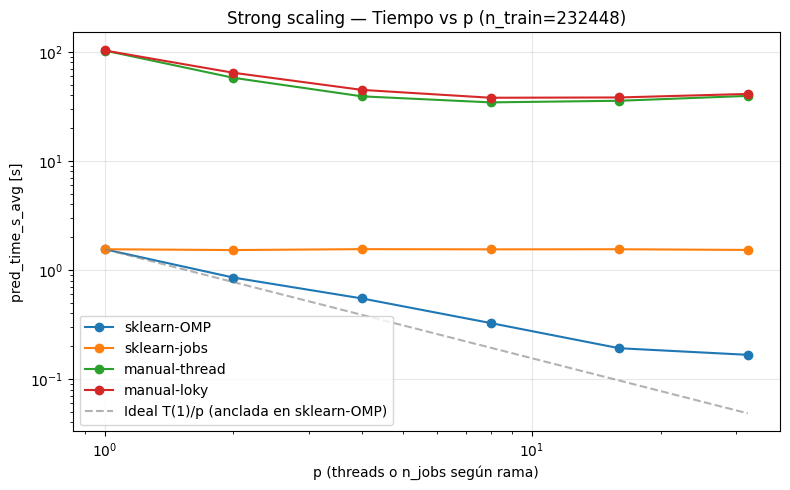

In [5]:
# Figura 2.1: tiempo vs p (log-log) — 4 ramas overlaid + ideal T(1)/p
fig, ax = plt.subplots()
for branch, color in BRANCH_COLORS.items():
    s = strong_tables[branch]
    ax.loglog(s["p"], s["pred_time_s_avg"], "o-", color=color, label=branch)

# Curva ideal anclada en T(p=1) de sklearn-OMP
T1_sk = strong_tables["sklearn-OMP"]["pred_time_s_avg"].iloc[0]
ps = np.array(P_VALS)
ax.loglog(ps, T1_sk / ps, "--", color="gray", alpha=0.6,
          label=f"Ideal T(1)/p (anclada en sklearn-OMP)")

ax.set_xlabel("p (threads o n_jobs según rama)")
ax.set_ylabel("pred_time_s_avg [s]")
ax.set_title(f"Strong scaling — Tiempo vs p (n_train={N_TRAIN_BIG})")
ax.legend()
plt.tight_layout()
plt.show()


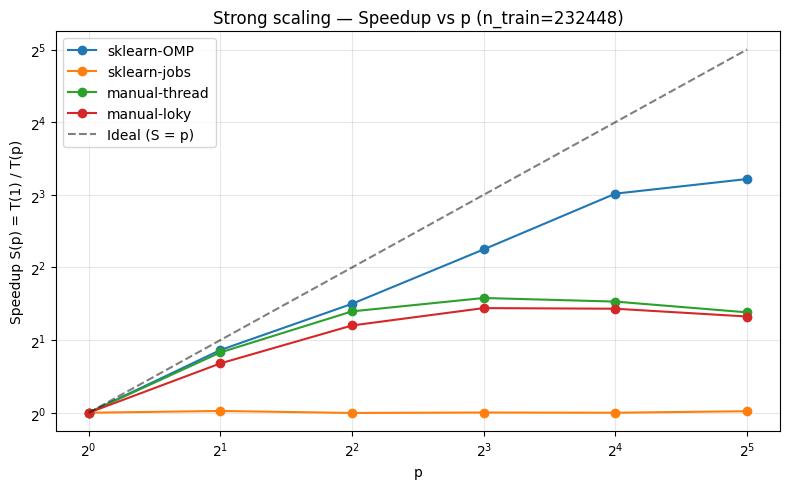

In [6]:
# Figura 2.2: speedup vs p (log-log base 2) — 4 ramas + diagonal ideal
fig, ax = plt.subplots()
for branch, color in BRANCH_COLORS.items():
    s = strong_tables[branch]
    ax.plot(s["p"], s["speedup"], "o-", color=color, label=branch)
ax.plot(P_VALS, P_VALS, "k--", alpha=0.5, label="Ideal (S = p)")

ax.set_xscale("log", base=2)
ax.set_yscale("log", base=2)
ax.set_xlabel("p")
ax.set_ylabel("Speedup S(p) = T(1) / T(p)")
ax.set_title(f"Strong scaling — Speedup vs p (n_train={N_TRAIN_BIG})")
ax.legend()
plt.tight_layout()
plt.show()


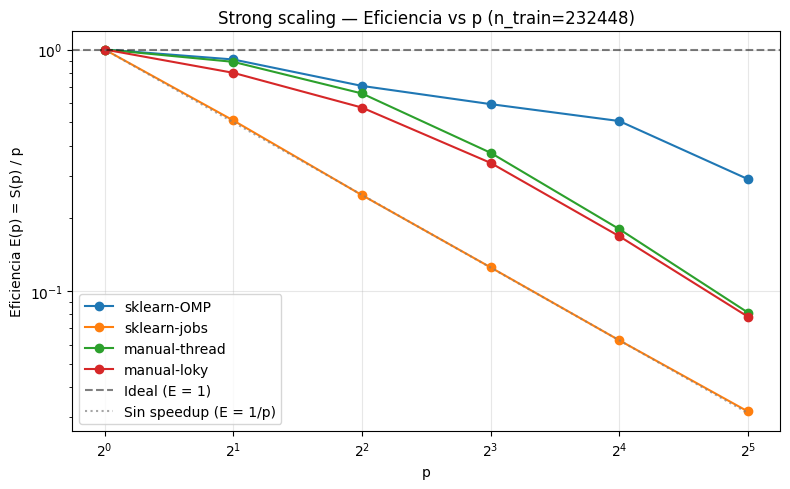

In [7]:
# Figura 2.3: eficiencia vs p — 4 ramas + ideal=1 + sin-speedup=1/p
fig, ax = plt.subplots()
for branch, color in BRANCH_COLORS.items():
    s = strong_tables[branch]
    ax.plot(s["p"], s["efficiency"], "o-", color=color, label=branch)

ax.axhline(1.0, color="k", linestyle="--", alpha=0.5, label="Ideal (E = 1)")
ax.plot(P_VALS, [1.0/p for p in P_VALS], ":", color="gray", alpha=0.7,
        label="Sin speedup (E = 1/p)")

ax.set_xscale("log", base=2)
ax.set_yscale("log")
ax.set_xlabel("p")
ax.set_ylabel("Eficiencia E(p) = S(p) / p")
ax.set_title(f"Strong scaling — Eficiencia vs p (n_train={N_TRAIN_BIG})")
ax.legend()
plt.tight_layout()
plt.show()


### Conclusiones — escalabilidad fuerte

_TODO: completar a partir de las gráficas 2.1–2.3._

- ¿Qué ramas paralelizan efectivamente y cuáles son no-op?
- ¿Dónde satura cada rama (p óptimo) y qué lo explica (memory bandwidth, hyperthreads, overhead joblib)?
- ¿Cuál es el speedup pico observado y la eficiencia en ese punto?
- Comparación absoluta sklearn vs manual: ¿cuánto más rápido es uno que el otro incluso optimizados al máximo?

## 3. Escalabilidad débil

Emparejamos `p` con `n_train` por índice del grid (`mult_train` crece 4× cada paso, `p` crece 2× cada paso):

| p | mult_train | n_train | n_train / p |
|---|---|---|---|
| 1 | 1 | 227 | 227 |
| 2 | 4 | 908 | 454 |
| 4 | 16 | 3632 | 908 |
| 8 | 64 | 14528 | 1816 |
| 16 | 256 | 58112 | 3632 |
| 32 | 1024 | 232448 | 7264 |

> **Nota:** la razón `n_train / p` **no es constante** (duplica cada paso), así que el ideal estricto de escalabilidad débil (curva de tiempo plana) no aplica con rigor: cada paso aumenta tanto el paralelismo como el trabajo por hilo. Se interpreta como tendencia relativa al baseline `(p=1, n_train=227)`. Para weak scaling estricto haría falta un grid con `n_train ∝ p` (ratio constante).

In [8]:
# Pares weak scaling (mult_train ×4 por paso, p ×2 por paso → ratio NO constante)
WEAK_PAIRS = list(zip([1, 2, 4, 8, 16, 32], [227, 908, 3632, 14528, 58112, 232448]))

def weak_table(branch):
    rows = []
    for p, n in WEAK_PAIRS:
        s = extract_branch(df, branch, n)
        sel = s[s["p"] == p]
        if not len(sel):
            continue
        rows.append({"p": p, "n_train": n, "pred_time": sel["pred_time_s_avg"].iloc[0]})
    out = pd.DataFrame(rows)
    T1 = out["pred_time"].iloc[0]
    out["weak_speedup"]    = T1 * out["p"] / out["pred_time"]
    out["weak_efficiency"] = T1 / out["pred_time"]
    return out

weak_tables = {b: weak_table(b) for b in BRANCH_COLORS}
for b, t in weak_tables.items():
    print(f"\n=== {b} ===")
    print(t.round(3).to_string(index=False))



=== sklearn-OMP ===
 p  n_train  pred_time  weak_speedup  weak_efficiency
 1      227      0.003         1.000            1.000
 2      908      0.006         1.051            0.525
 4     3632      0.012         1.060            0.265
 8    14528      0.027         0.925            0.116
16    58112      0.055         0.900            0.056
32   232448      0.166         0.596            0.019

=== sklearn-jobs ===
 p  n_train  pred_time  weak_speedup  weak_efficiency
 1      227      0.003         1.000            1.000
 2      908      0.008         0.816            0.408
 4     3632      0.026         0.475            0.119
 8    14528      0.096         0.258            0.032
16    58112      0.382         0.130            0.008
32   232448      1.526         0.065            0.002

=== manual-thread ===
 p  n_train  pred_time  weak_speedup  weak_efficiency
 1      227      0.062         1.000            1.000
 2      908      0.168         0.735            0.367
 4     3632     

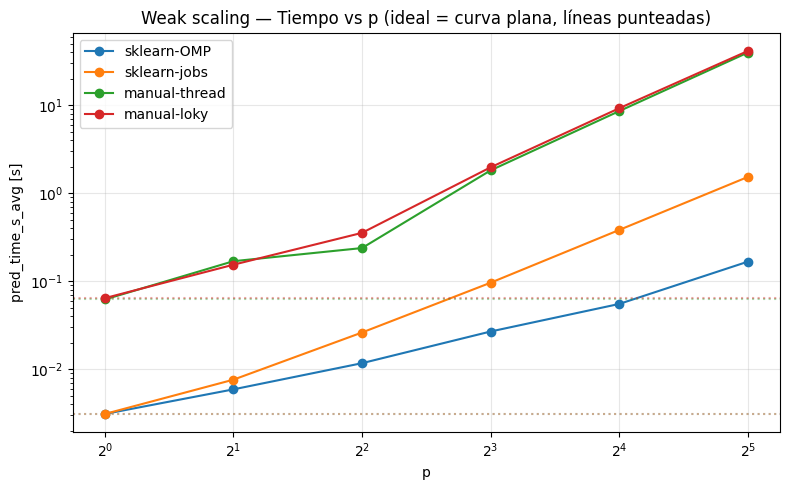

In [9]:
# Figura 3.1: weak time vs p — 4 ramas + línea ideal (T plana por rama)
fig, ax = plt.subplots()
WEAK_P = [p for p, _ in WEAK_PAIRS]
for branch, color in BRANCH_COLORS.items():
    t = weak_tables[branch]
    ax.plot(t["p"], t["pred_time"], "o-", color=color, label=branch)
    # Tiempo ideal "plano" anclado en T_w(p=1) de cada rama
    ax.axhline(t["pred_time"].iloc[0], color=color, linestyle=":", alpha=0.4)

ax.set_xscale("log", base=2)
ax.set_yscale("log")
ax.set_xlabel("p")
ax.set_ylabel("pred_time_s_avg [s]")
ax.set_title("Weak scaling — Tiempo vs p (ideal = curva plana, líneas punteadas)")
ax.legend()
plt.tight_layout()
plt.show()


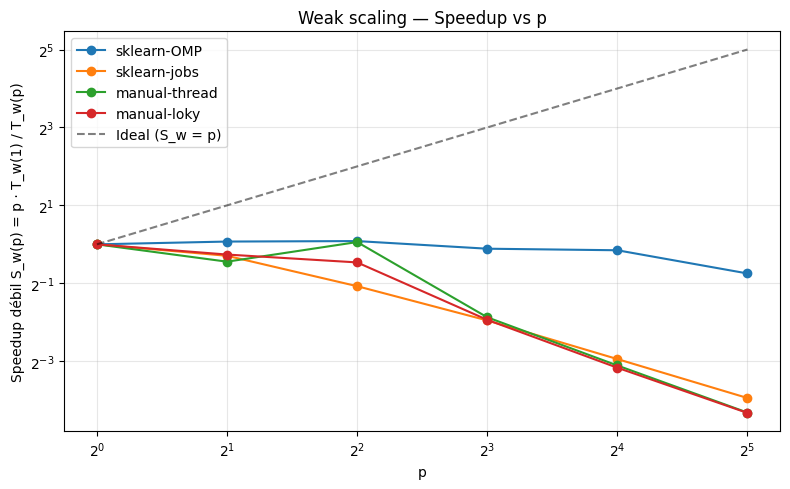

In [10]:
# Figura 3.2: weak speedup vs p — 4 ramas + diagonal ideal
fig, ax = plt.subplots()
for branch, color in BRANCH_COLORS.items():
    t = weak_tables[branch]
    ax.plot(t["p"], t["weak_speedup"], "o-", color=color, label=branch)
ax.plot(WEAK_P, WEAK_P, "k--", alpha=0.5, label="Ideal (S_w = p)")

ax.set_xscale("log", base=2)
ax.set_yscale("log", base=2)
ax.set_xlabel("p")
ax.set_ylabel("Speedup débil S_w(p) = p · T_w(1) / T_w(p)")
ax.set_title("Weak scaling — Speedup vs p")
ax.legend()
plt.tight_layout()
plt.show()


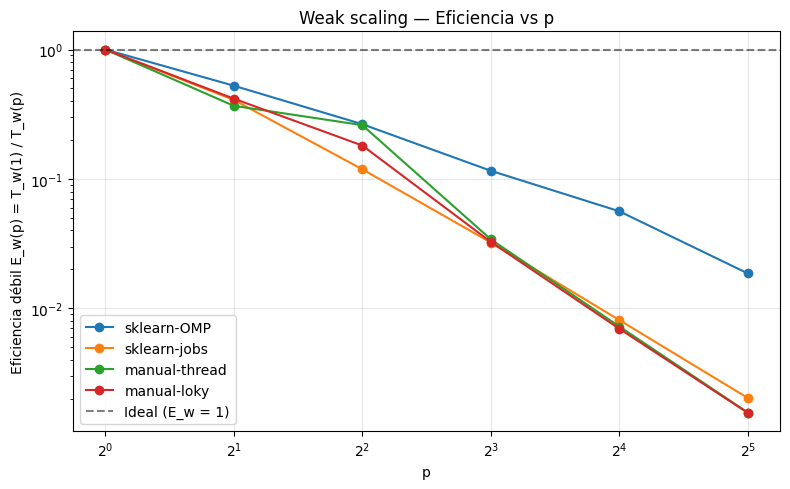

In [11]:
# Figura 3.3: weak efficiency vs p — 4 ramas + ideal=1
fig, ax = plt.subplots()
for branch, color in BRANCH_COLORS.items():
    t = weak_tables[branch]
    ax.plot(t["p"], t["weak_efficiency"], "o-", color=color, label=branch)

ax.axhline(1.0, color="k", linestyle="--", alpha=0.5, label="Ideal (E_w = 1)")
ax.set_xscale("log", base=2)
ax.set_yscale("log")
ax.set_xlabel("p")
ax.set_ylabel("Eficiencia débil E_w(p) = T_w(1) / T_w(p)")
ax.set_title("Weak scaling — Eficiencia vs p")
ax.legend()
plt.tight_layout()
plt.show()


### Conclusiones — escalabilidad débil

_TODO_

- ¿Qué tan plana es la curva de tiempo por rama? ¿Alguna se acerca al ideal?
- ¿Cómo se comparan strong vs weak en términos de eficiencia (mismo `p`)?
- Limitación del grid: pares con razón `n_train/p` no constante (crece 2× por paso). ¿Cómo afecta la interpretación?

## 4. Overhead

Reutiliza el caso BIG (`n_train = 232 448`). Definimos:

- **Overhead absoluto:** $O(p) = T(p) - T(1)/p$ — exceso medido sobre la curva ideal.
- **Fracción de overhead:** $O(p) / T(p)$ — qué proporción del tiempo total es sobrecarga (1 = todo overhead).

In [12]:
# Tablas de overhead por rama en BIG
def overhead_table(branch):
    s = strong_tables[branch].copy()
    T1 = s[s["p"] == 1]["pred_time_s_avg"].iloc[0]
    s["ideal"] = T1 / s["p"]
    s["overhead_abs"]  = s["pred_time_s_avg"] - s["ideal"]
    s["overhead_frac"] = s["overhead_abs"] / s["pred_time_s_avg"]
    return s[["p", "pred_time_s_avg", "ideal", "overhead_abs", "overhead_frac"]]

overhead_tables = {b: overhead_table(b) for b in BRANCH_COLORS}
for b, t in overhead_tables.items():
    print(f"\n=== {b} ===")
    print(t.round(4).to_string(index=False))



=== sklearn-OMP ===
 p  pred_time_s_avg  ideal  overhead_abs  overhead_frac
 1           1.5483 1.5483        0.0000         0.0000
 2           0.8513 0.7742        0.0771         0.0906
 4           0.5477 0.3871        0.1606         0.2933
 8           0.3258 0.1935        0.1323         0.4060
16           0.1914 0.0968        0.0946         0.4944
32           0.1665 0.0484        0.1181         0.7094

=== sklearn-jobs ===
 p  pred_time_s_avg  ideal  overhead_abs  overhead_frac
 1           1.5483 1.5483        0.0000         0.0000
 2           1.5224 0.7742        0.7482         0.4915
 4           1.5516 0.3871        1.1645         0.7505
 8           1.5450 0.1935        1.3515         0.8747
16           1.5482 0.0968        1.4514         0.9375
32           1.5261 0.0484        1.4777         0.9683

=== manual-thread ===
 p  pred_time_s_avg    ideal  overhead_abs  overhead_frac
 1         102.9248 102.9248        0.0000         0.0000
 2          57.8898  51.4624      

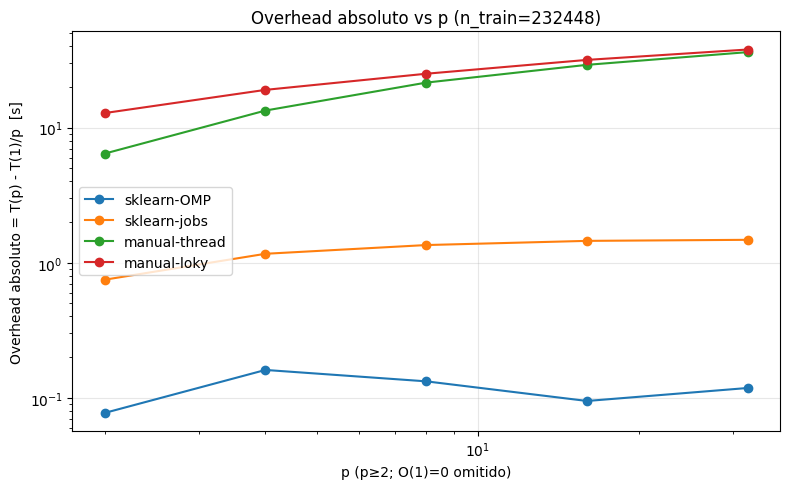

In [13]:
# Figura 4.1: overhead absoluto vs p (log-log, p=1 omitido)
fig, ax = plt.subplots()
for branch, color in BRANCH_COLORS.items():
    t = overhead_tables[branch]
    t2 = t[t["p"] > 1]
    ax.loglog(t2["p"], t2["overhead_abs"], "o-", color=color, label=branch)

ax.set_xlabel("p (p≥2; O(1)=0 omitido)")
ax.set_ylabel("Overhead absoluto = T(p) - T(1)/p  [s]")
ax.set_title(f"Overhead absoluto vs p (n_train={N_TRAIN_BIG})")
ax.legend()
plt.tight_layout()
plt.show()


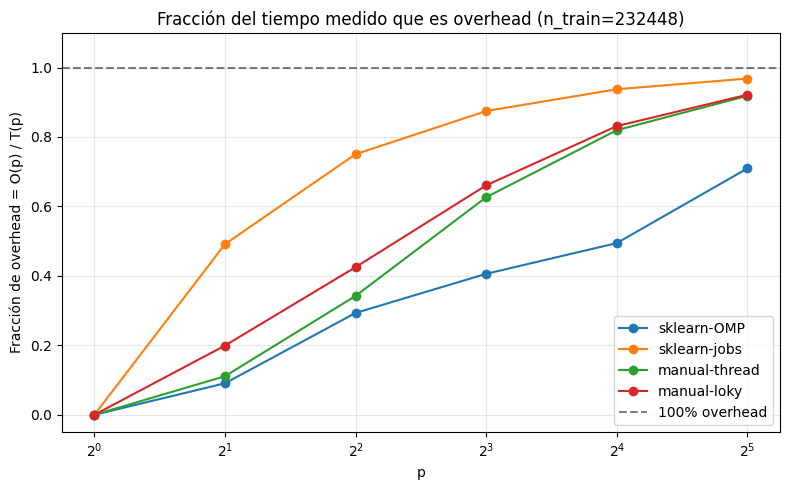

In [14]:
# Figura 4.2: fracción de overhead vs p (lineal 0–1)
fig, ax = plt.subplots()
for branch, color in BRANCH_COLORS.items():
    t = overhead_tables[branch]
    ax.plot(t["p"], t["overhead_frac"], "o-", color=color, label=branch)

ax.axhline(1.0, color="k", linestyle="--", alpha=0.5, label="100% overhead")
ax.set_xscale("log", base=2)
ax.set_xlabel("p")
ax.set_ylabel("Fracción de overhead = O(p) / T(p)")
ax.set_title(f"Fracción del tiempo medido que es overhead (n_train={N_TRAIN_BIG})")
ax.set_ylim(-0.05, 1.10)
ax.legend()
plt.tight_layout()
plt.show()


### Conclusiones — overhead

_TODO_

- ¿En qué rama el overhead crece más rápido con `p`?
- ¿En qué momento la fracción de overhead supera el 50% / 90%? ¿Coincide con la saturación del speedup observada en §2?
- Implicaciones prácticas: ¿cuál es el `p` óptimo por rama y por qué pasarlo es contraproducente?

## 5. Resumen ejecutivo

Cifras clave de strong scaling sobre el caso BIG (`n_train = 232 448`, `d = 88`, `n_test = 1216`) para cada rama.

In [15]:
# Tabla resumen: T(1), best T, speedup máximo, p óptimo, eficiencia en p óptimo
rows = []
for branch in BRANCH_COLORS:
    t = strong_tables[branch]
    T1 = t[t["p"] == 1]["pred_time_s_avg"].iloc[0]
    best_idx = t["pred_time_s_avg"].idxmin()
    p_opt = int(t.loc[best_idx, "p"])
    T_opt = t.loc[best_idx, "pred_time_s_avg"]
    sp_max = T1 / T_opt
    eff_opt = sp_max / p_opt
    rows.append({
        "rama": branch,
        "T(1) [s]": round(T1, 4),
        "T(óptimo) [s]": round(T_opt, 4),
        "p óptimo": p_opt,
        "speedup máx": round(sp_max, 2),
        "eficiencia @ óptimo": round(eff_opt, 3),
    })
summary = pd.DataFrame(rows)
print("Resumen strong scaling en BIG:")
print(summary.to_string(index=False))


Resumen strong scaling en BIG:
         rama  T(1) [s]  T(óptimo) [s]  p óptimo  speedup máx  eficiencia @ óptimo
  sklearn-OMP    1.5483         0.1665        32         9.30                0.291
 sklearn-jobs    1.5483         1.5224         2         1.02                0.509
manual-thread  102.9248        34.4398         8         2.99                0.374
  manual-loky  103.0885        37.9844         8         2.71                0.339


_TODO — conclusión final (1 párrafo):_

Resumir en 3-4 oraciones el mensaje principal:
1. Cuál es la palanca correcta de paralelismo para cada implementación.
2. Cuál es el speedup pico y dónde se obtiene.
3. Qué tradeoffs implementación / paralelismo deja la tarea.